In [2]:
import torch
import matplotlib.pyplot as plt

In [189]:
# Apple (mps) GPU 

device = "mps" if torch.backends.mps.is_available() else "cpu"

In [197]:
## Linear Regression class

class LinearRegression(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_layer = torch.nn.Linear(
            in_features = 1,
            out_features = 1
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

In [198]:
weight = 0.7
bias = 0.3

torch.manual_seed(42)

X = torch.arange(0, 10, 0.1, device = device).unsqueeze(dim=1)
y = bias + weight * X

split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [199]:
model = LinearRegression()
model.to(device)

LinearRegression(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

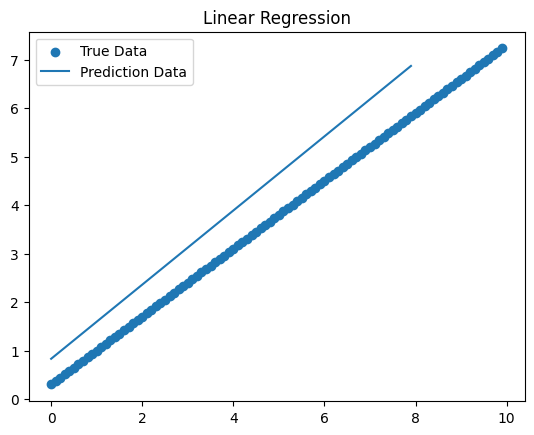

In [200]:
with torch.inference_mode():
    y_pred = model(X_train)

plt.scatter(X.cpu(), y.cpu(), label="True Data")
plt.plot(X_train.cpu(), y_pred.cpu(), label="Prediction Data")
plt.legend()
plt.title("Linear Regression")
plt.show()

In [201]:
epochs = 100
epoch_count = []
losses = []
test_losses = []

torch.manual_seed(42)

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

for epoch in range(epochs):
    model.train()

    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    model.eval()

    with torch.inference_mode():
        test_y_pred = model(X_test)
        test_loss = loss_fn(test_y_pred, y_test)
        test_losses.append(test_loss.item())
        
    epoch_count.append(epoch)

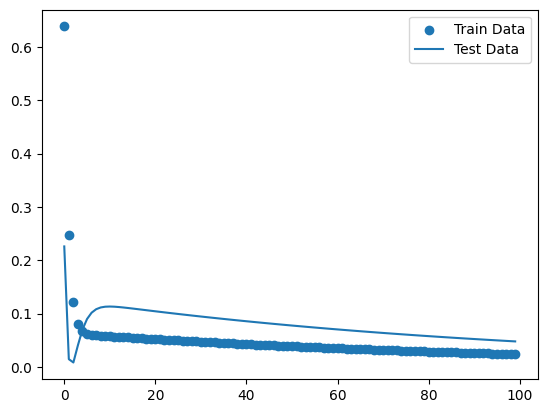

In [202]:
plt.scatter(epoch_count, losses, label = "Train Data")
plt.plot(epoch_count, test_losses, label = "Test Data")
plt.legend()
plt.show()

In [211]:
with torch.inference_mode():
    model_y_pred = model(X_test)

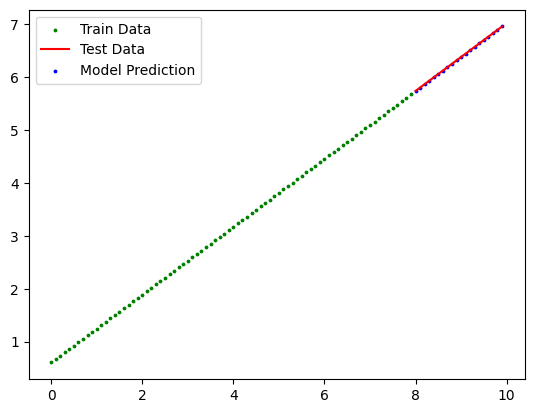

In [216]:
plt.scatter(X_train.cpu(), y_pred.cpu().detach().numpy(), label = "Train Data", s = 3, color = "green")
plt.plot(X_test.cpu(), test_y_pred.cpu().detach().numpy(), label = "Test Data", color = "red")
plt.scatter(X_test.cpu(), model_y_pred.cpu().detach().numpy(), label = "Model Prediction", s = 3, color = "blue")
plt.legend()
plt.show()